# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [19]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Néstor Iram Zaragoza Sánchez"            # Tu nombre completo
MATRICULA = "82050"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "desnutricion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Néstor Iram Zaragoza Sánchez
Matrícula: 82050
Dataset asignado: desnutricion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [20]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\nesso\Downloads\ExamenParcial1\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: desnutricion
Descripcion: Numero de personas subalimentadas (desnutricion) (personas)


In [22]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [23]:
df.head(25)

,entity,code,year,valor
0,Afghanistan,AFG,2001,9400000.0
1,Afghanistan,AFG,2002,9300000.0
2,Afghanistan,AFG,2003,8700000.0
3,Afghanistan,AFG,2004,8200000.0
4,Afghanistan,AFG,2005,7500000.0
5,Afghanistan,AFG,2006,6700000.0
6,Afghanistan,AFG,2007,5900000.0
7,Afghanistan,AFG,2008,5200000.0
8,Afghanistan,AFG,2009,4800000.0
9,Afghanistan,AFG,2010,5000000.0


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [24]:
# Forma del dataset (filas, columnas)
df.shape


(3544, 4)

In [25]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   entity  3544 non-null   str    
 1   code    2758 non-null   str    
 2   year    3544 non-null   int64  
 3   valor   3544 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 110.9 KB


In [26]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    3.544000e+03
mean     3.061574e+07
std      8.749230e+07
min      1.000000e+05
25%      3.000000e+05
50%      2.100000e+06
75%      9.925000e+06
max      8.252000e+08
Name: valor, dtype: float64

In [27]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity      0
code      786
year        0
valor       0
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

Veo que existe solo valores nulos en el apartado de Code, además de que en el mismo es un tipo de dato String, probablemente sea que haya algunos paises que estén como separados por "estados" o facciones, por ejemplo, que sea Africa pero de muchos otros lados.

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [28]:
# Pregunta 1
# Tu codigo aqui

col_filtro = config['filtro_paises']

df_paises = df.dropna(subset=[col_filtro]).copy()

df_paises = df_paises[~df_paises[col_filtro].str.startswith('OWID_')]

num_paises = df_paises['entity'].nunique()
print(f"Hay {num_paises} países distintos en el dataset.\n")

ranking = df_paises.groupby('entity')['valor'].mean().sort_values(ascending=False)

print("10 PAÍSES CON MAYOR VALOR")
print(ranking.head(10))

print("\n10 PAÍSES CON MENOR VALOR")
print(ranking.tail(10))


Hay 139 países distintos en el dataset.

10 PAÍSES CON MAYOR VALOR
entity
India                           1.875739e+08
China                           8.724444e+07
Pakistan                        3.121304e+07
Indonesia                       2.811739e+07
Democratic Republic of Congo    2.382174e+07
Ethiopia                        2.264783e+07
Bangladesh                      2.238261e+07
Nigeria                         2.161739e+07
Tanzania                        1.180000e+07
Philippines                     1.175652e+07
Name: valor, dtype: float64

10 PAÍSES CON MENOR VALOR
entity
New Caledonia                       100000.0
Mauritius                           100000.0
Samoa                               100000.0
Sao Tome and Principe               100000.0
Saint Vincent and the Grenadines    100000.0
North Macedonia                     100000.0
Suriname                            100000.0
Seychelles                          100000.0
Vanuatu                             100000.0
Uruguay  

**Interpretación:**

Existen 139 países distintos, los 10 países con un mayor promedio quiere decir que son los 10 países donde existe más desnutrición, en los otros 10, son los paises que tienen nada o casi nada de nutrición. Probablemente sean países donde no haya muchos habitantes o donde la economía no esté muy mal.

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [29]:
# Pregunta 2
# Tu codigo aqui

pais1 = 'Mexico'
pais2 = 'Colombia'

anios_pais1 = set(df_paises[df_paises['entity'] == pais1]['year'])
anios_pais2 = set(df_paises[df_paises['entity'] == pais2]['year'])

anios_comunes = anios_pais1.intersection(anios_pais2)

filtro = (df_paises['entity'].isin([pais1, pais2])) & (df_paises['year'].isin(anios_comunes))
df_dos_paises = df_paises[filtro]

df_dos_paises = df_dos_paises.sort_values(by=['entity', 'year'])
print(df_dos_paises)


        entity code  year      valor
641   Colombia  COL  2001  3400000.0
642   Colombia  COL  2002  3600000.0
643   Colombia  COL  2003  3900000.0
644   Colombia  COL  2004  4300000.0
645   Colombia  COL  2005  4600000.0
646   Colombia  COL  2006  4800000.0
647   Colombia  COL  2007  4700000.0
648   Colombia  COL  2008  4800000.0
649   Colombia  COL  2009  4900000.0
650   Colombia  COL  2010  5000000.0
651   Colombia  COL  2011  4500000.0
652   Colombia  COL  2012  3900000.0
653   Colombia  COL  2013  3300000.0
654   Colombia  COL  2014  2700000.0
655   Colombia  COL  2015  2300000.0
656   Colombia  COL  2016  2100000.0
657   Colombia  COL  2017  2000000.0
658   Colombia  COL  2018  2100000.0
659   Colombia  COL  2019  2100000.0
660   Colombia  COL  2020  2100000.0
661   Colombia  COL  2021  2100000.0
662   Colombia  COL  2022  2100000.0
663   Colombia  COL  2023  2000000.0
1964    Mexico  MEX  2001  2800000.0
1965    Mexico  MEX  2002  3300000.0
1966    Mexico  MEX  2003  3900000.0
1

**Interpretación:**

Al observar el DataFrame, se puede ver que tanto México como Colombia tienen disponibilidad de datos exactamente para el mismo rango de años. Aunque así por encima no se puede notar, pero el número de personas que están muy alimentadas en México suele ser ligeramente mayor que en Colombia. Pero eso sí, este comportamiento es esperado y proporcional, ya que la población total de México es significativamente mayor a la de Colombia.

### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [30]:
# Pregunta 3
# Tu codigo aqui

paises_q3 = ['India', 'Brazil', 'Nigeria', 'China', 'Mexico']

anio_reciente = df_paises['year'].max()

df_q3 = df_paises[(df_paises['entity'].isin(paises_q3)) & (df_paises['year'] == anio_reciente)]
df_q3 = df_q3.sort_values('valor', ascending=False)
print(df_q3[['entity', 'year', 'valor']])

max_val = df_q3['valor'].max()
min_val = df_q3['valor'].min()
print(f"\nDiferencia entre el país con valor más alto y más bajo: {max_val - min_val:,.0f} personas")


       entity  year        valor
1360    India  2023  172100000.0
2260  Nigeria  2023   45400000.0
1986   Mexico  2023    3500000.0

Diferencia entre el país con valor más alto y más bajo: 168,600,000 personas


**Interpretación:**
Al comparar estos países en el año 2023, India presenta el nivel más crítico con más de 172 millones de personas afectadas, mientras que otros como México presentan cifras muchísimo menores en comparación con India. La abismal diferencia de más de 168 millones refleja no solo que hay mayores crisis alimentarias en Asia, sino también la enorme desigualdad que se da al comparar países con densidades de población extremadamente distintas.


### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [31]:
# Pregunta 4
# Tu codigo aqui

grupo_latam = ['Mexico', 'Colombia', 'Argentina']
grupo_asia = ['India', 'Pakistan', 'Vietnam'] 

anio_reciente = df_paises['year'].max()

df_latam = df_paises[(df_paises['entity'].isin(grupo_latam)) & (df_paises['year'] == anio_reciente)]
df_asia = df_paises[(df_paises['entity'].isin(grupo_asia)) & (df_paises['year'] == anio_reciente)]

promedio_latam = df_latam['valor'].mean()
promedio_asia = df_asia['valor'].mean()

print(f"Promedio de desnutrición LATAM ({anio_reciente}): {promedio_latam:,.0f} personas")
print(f"Promedio de desnutrición ASIA ({anio_reciente}): {promedio_asia:,.0f} personas")


Promedio de desnutrición LATAM (2023): 2,333,333 personas
Promedio de desnutrición ASIA (2023): 72,766,667 personas


**Interpretación:**

Al agrupar y promediar, observamos que la muestra seleccionada de Asia tiene un promedio de personas subalimentadas inmensamente mayor comparado con el promedio de nuestro grupo en Latam. Esto nos muestra que las crisis demográficas y alimentarias actuales golpean numéricamente de forma mucho más severa a ciertos sectores de Asia que a la región de latam.

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [32]:
# Pregunta 5
# Tu codigo aqui

pais_q5 = 'Mexico'
df_mexico = df_paises[df_paises['entity'] == pais_q5].sort_values('year')

max_row = df_mexico.loc[df_mexico['valor'].idxmax()]
min_row = df_mexico.loc[df_mexico['valor'].idxmin()]

print(f"País analizado: {pais_q5}")
print(f"Pico Máximo: {max_row['valor']:,.0f} personas en el año {max_row['year']}")
print(f"Punto Mínimo: {min_row['valor']:,.0f} personas en el año {min_row['year']}")


País analizado: Mexico
Pico Máximo: 4,600,000 personas en el año 2009
Punto Mínimo: 2,800,000 personas en el año 2001


**Interpretación:**

En este caso, usé a México como referencia. Podemos ver que a lo largo de estas dos décadas los cambios y datos han sido bastante cambiantes. Primero, se inició con 2.8 millones en 2001, y subió muy drástico hasta alcanzar 4.6 millones de desnutridos en 2009-2010 y 2017, que fueron en los años donde la moneda mexicana se fue para abajo. Lo importantes es que, en los años muy recientes, los datos han disminuido hasta 3.5 millones.

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [33]:
# Pregunta 6
# Tu codigo aqui

pais_q6 = 'Mexico'
df_mex = df_paises[df_paises['entity'] == pais_q6].sort_values('year')

primer_valor = df_mex.iloc[0]['valor']
ultimo_valor = df_mex.iloc[-1]['valor']

cambio_pct = ((ultimo_valor - primer_valor) / primer_valor) * 100

print(f"Valor inicial (2001): {primer_valor:,.0f}")
print(f"Valor final (2023): {ultimo_valor:,.0f}")
print(f"Cambio porcentual: {cambio_pct:.2f}%")


Valor inicial (2001): 2,800,000
Valor final (2023): 3,500,000
Cambio porcentual: 25.00%


**Interpretación:**

Sorprendentemente, a pesar del ligero descenso de los últimos tres años, al evaluar todo el historial, México presenta un incremento del 25% en su número de personas subalimentadas. Creo que este resultado se debe a que el rápido crecimiento del país y la constante devaluación/inflación de la canasta básica han avanzado más rápido de lo que los programas de asistencia social han logrado contener en 22 años.

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [34]:
# Pregunta 7
# Tu codigo aqui

anio_reciente = df_paises['year'].max()

valores_recientes = df_paises[df_paises['year'] == anio_reciente]['valor'].dropna().values

media = np.mean(valores_recientes)
mediana = np.median(valores_recientes)
desviacion = np.std(valores_recientes)

print(f"Estadísticas para el año {anio_reciente}:")
print(f"Media: {media:,.2f}")
print(f"Mediana: {mediana:,.2f}")
print(f"Desviación Estándar: {desviacion:,.2f}")


Estadísticas para el año 2023:
Media: 5,884,761.90
Mediana: 1,600,000.00
Desviación Estándar: 18,150,375.99


**Interpretación:**

La gran diferencia entre la media y la mediana, sumado a una desviación estándar bastante grotesca, indica que los datos están fuertemente 'sesgados' a la derecha. Osease, la gran mayoría de los países del mundo tienen niveles controlados, pero existen unos cuantos 'outliers' con cientos de millones de afectados que arrastran drásticamente el promedio global hacia arriba.

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

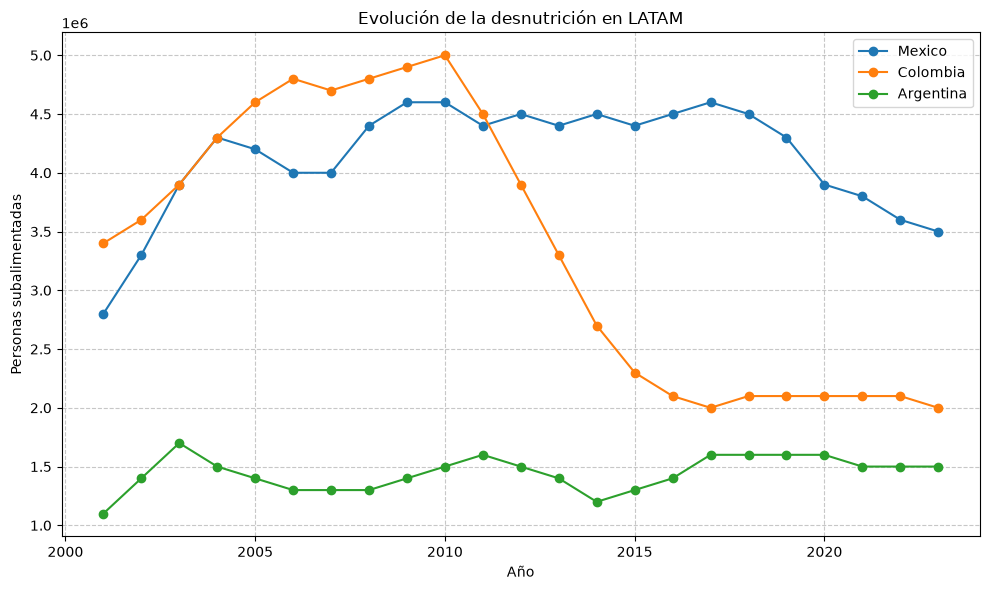

In [35]:
# Pregunta 8
# Tu codigo aqui

paises_plot = ['Mexico', 'Colombia', 'Argentina']
plt.figure(figsize=(10, 6))

for pais in paises_plot:
    datos_pais = df_paises[df_paises['entity'] == pais].sort_values('year')
    plt.plot(datos_pais['year'], datos_pais['valor'], marker='o', label=pais)

plt.title('Evolución de la desnutrición en LATAM')
plt.xlabel('Año')
plt.ylabel('Personas subalimentadas')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Interpretación:**

La gráfica de líneas nos muestra algo curioso: Argentina mantiene una línea que está prácticamente plana y estable en la parte inferior, mientras que Colombia logró hacer que disminuyeran los datos muy drasticamente con los años, que la verdad, es un gran logro. México, en contraste, ocupa la parte alta de la gráfica dejando ver el estancamiento y la alta fluctuación de sus cifras durante la última década.

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

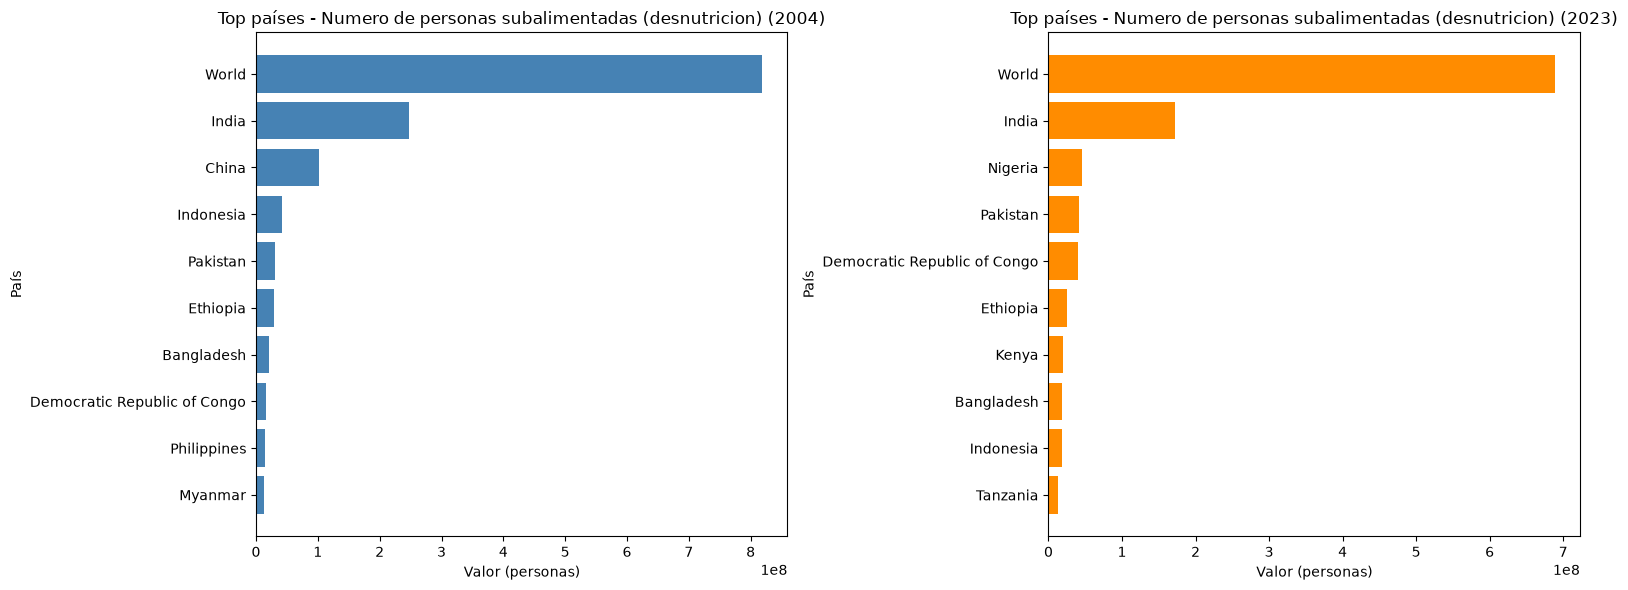

In [36]:

df_paises = df[df[config["filtro_paises"]].notnull()]

anio_nacimiento = 2004
anio_reciente = 2023


top_nac = (
    df_paises[df_paises['year'] == anio_nacimiento]
    .sort_values('valor', ascending=False)
    .head(10)
)

top_reciente = (
    df_paises[df_paises['year'] == anio_reciente]
    .sort_values('valor', ascending=False)
    .head(10)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_nac['entity'], top_nac['valor'], color='steelblue')
axes[0].set_xlabel(f"Valor ({config['unidad']})")
axes[0].set_ylabel("País")
axes[0].set_title(f"Top países - {config['descripcion']} ({anio_nacimiento})")
axes[0].invert_yaxis()

axes[1].barh(top_reciente['entity'], top_reciente['valor'], color='darkorange')
axes[1].set_xlabel(f"Valor ({config['unidad']})")
axes[1].set_ylabel("País")
axes[1].set_title(f"Top países - {config['descripcion']} ({anio_reciente})")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


**Interpretación:**

Al comparar ambas barras horizontales, se puede notar que la India lidera en ambas décadas por un margen inmenso. El movimiento más importante es que China abandonó el Top 10. Sin embargo, su lugar fue sustituido por naciones emergentes africanas, confirmando que el epicentro del hambre mundial se está trasladando lentamente del este de Asia hacia el continente africano.

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

Al analizar este dataset, descubrí que las crisis alimentarias globales son sumamente desiguales, afectando desproporcionadamente a ciertos países dependiendo del tamaño de su población. Además, fue revelador notar que no todos los países presentan una mejora natural con el tiempo, como el aumento porcentual que registró México en estas dos décadas. La principal limitación del dataset es que los valores están en 'personas absolutas'; para un análisis estadísticamente más justo y preciso, lo ideal habría sido normalizar los datos dividiendo estas cifras entre la población total de cada país para sacar tasas 'per cápita', lo que permitiría ver el porcentaje real de afectación independientemente del tamaño de la nación.

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
